#Trabalho de Analise de Dados

Por Bruno Pasquali Berti

Dataset Escolhido: https://www.kaggle.com/datasets/mosapabdelghany/medical-insurance-cost-dataset

Se começa importando as bibliotecas para o trabalho

Este se trata de um Dataset que apresenta varios clientes de uma empresa de Seguro Médico, informações sobre eles e quanto eles foram cobrados pelo serviço.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.preprocessing import LabelEncoder

Aqui vemos um pequeno pedaço do dataset, nos permitindo entender sua estrutura

In [ ]:
insurence_data = pd.read_csv("/content/insurance.csv")
insurence_data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


Podemos ver aqui as colunas e os tipos de dados que os compoem

In [ ]:
insurence_data.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [ ]:
insurence_data.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


Pode-se deduzir os tipos de dados de cada coluna do Dataset:

- idade: Quantitativa Discreta
- Sexo: Qualitativa Nominal
- IMC: Quantitativa Continua
- Crianças: Quantitativa Discreta
- Fumante: Qualitativa Nominal
- Região: Qualitativa Nominal
- Valor cobrado: Quantitativa Continua

Aqui começamos a limpar os dados. Podemos ver que felizmente não há nenhuma tupla com valores nulos

In [ ]:
insurence_data.isna().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


Em seguida procuramos por Colunas duplicadas e encontramos 1 que então removida

In [ ]:
insurence_data.loc[insurence_data.duplicated()]

,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


In [ ]:
insurence_data.query('age == 19 and sex == "male" and bmi > 30.4 and bmi < 30.6')

,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


In [ ]:
insurence_data = insurence_data.drop_duplicates().copy()
insurence_data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


Com a limpeza dos dados prontos podemos prosseguir por uma analise básica

In [ ]:
insurence_data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


A Partir dessa simples analise podes ver algums fatos interesantes

1. Esse dataset contem apenas informações de adultos
2. Pelo menos metade das pessoas nesse dataset possuem Obesidade nivel I ou superior ( IMC > 30)
3. Mais de75% de todas as cobranças ultrapassam o salario mediano de um americano ( ~U$4.000,00)

Agora vamos criar alguns graficos de uma variavel

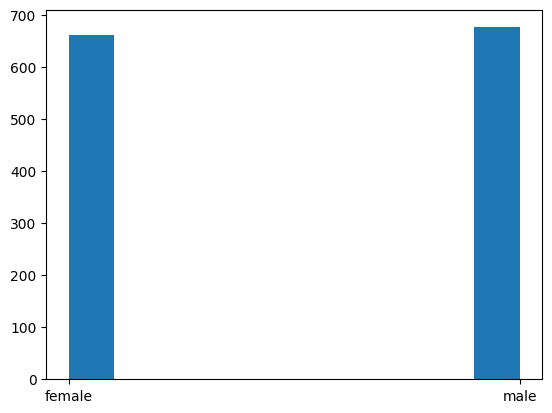

In [ ]:
plt.hist(x=insurence_data['sex']);

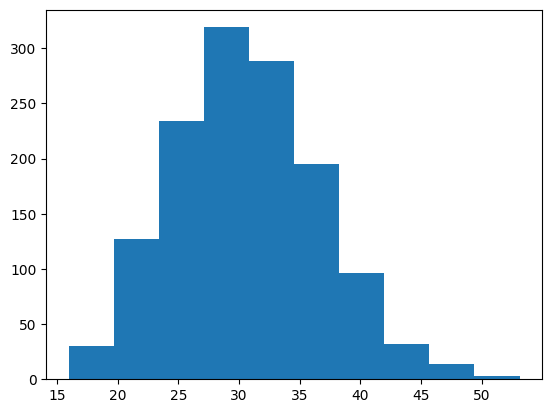

In [ ]:
plt.hist(x=insurence_data['bmi']);

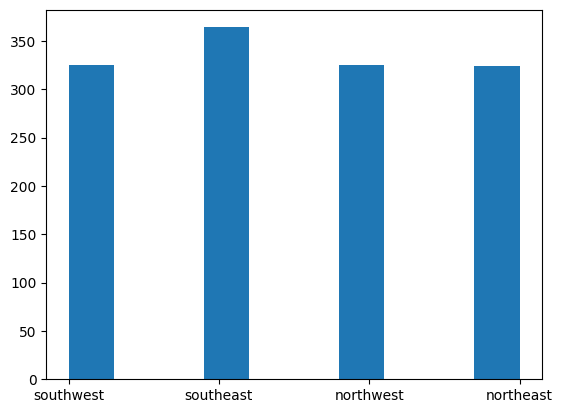

In [ ]:
plt.hist(x=insurence_data['region']);

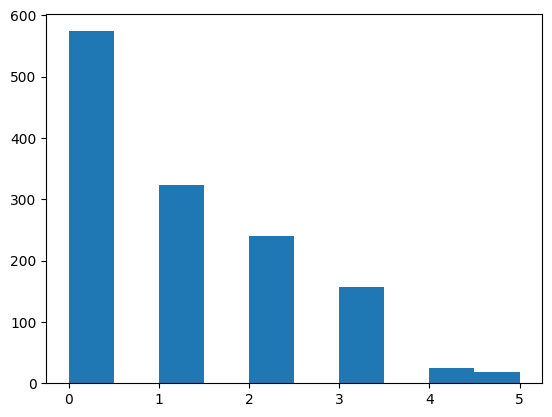

In [ ]:
plt.hist(x=insurence_data['children']);

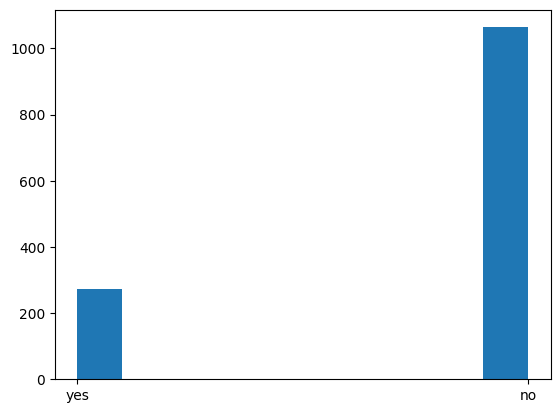

In [ ]:
plt.hist(x=insurence_data['smoker']);

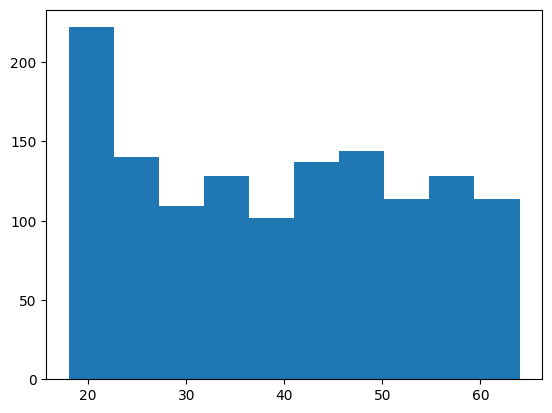

In [ ]:
plt.hist(x=insurence_data['age']);

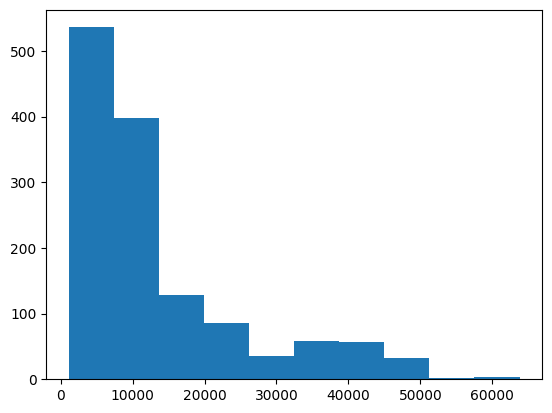

In [ ]:
plt.hist(x=insurence_data['charges']);

Esse gráficos já conseguiram nos trazer alguns insights:
1. O IMC é segue uma distribuição muito proxima de uma normal
2. Existe uma quantidade muito proxima de homens e mulheres no Dataset
3. Existe uma quantidade muito proxima de pessoas das 4 regiôes no Dataset
4. A maioria das pessoas desse Dataset não fumam

Vamos Seguir agora para gráficos com multiplas variaveis

In [ ]:
graph = px.treemap(insurence_data, path=['region', 'children'])
graph.show()

In [ ]:
graph4 = px.parallel_categories(insurence_data, dimensions=["smoker", "children"])
graph4.show()

In [ ]:
graph2 = px.scatter(insurence_data, x="age", y="charges", color = "sex",hover_name=  "bmi", symbol="smoker" )
graph2.show()

In [ ]:
graph3 = px.scatter(insurence_data, x="bmi", y="charges", color = "sex",hover_name=  "age", symbol="smoker")
graph3.show()

Nos dois ultimos gráficos podemos observar uma corelação entre as idades dos pacientes e o valor cobrado,  uma corelação entre as IMC dos pacientes e o valor cobrado e uma corelação entre ser fumante e o valor cobrado

Essas Corelções podem ser podem ser facilmente testadas

In [ ]:
print(np.corrcoef(insurence_data['age'],insurence_data['charges'])[0][1])
print(np.corrcoef(insurence_data['bmi'],insurence_data['charges'])[0][1])

0.29900819333064754
0.19834096883362895


In [ ]:
# Para checar se ser fumante tem corelação com o valor cobrado é preciso primero transforma-lo em um valor numerico
label_encoder = LabelEncoder()
SmokerEncoded = label_encoder.fit_transform(insurence_data["smoker"])
print(np.corrcoef(SmokerEncoded,insurence_data['charges'])[0][1])

0.7872514304984779


Vemos uma corelação fraca entre idade e valor cobrado e imc e valor cobra e uma corelação muito forte entre ser fumante e valor cobrado

#Criação de um modelo preditivo

Vamos agora criar um modelo para aproximar o valor cobrado com base em multiplas variaveis

In [ ]:
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense, Activation, Dropout

Primeiro vamos criar o Input. Escolhemos 4 variaveiss para o Input. Elas são:
- Idade
- Sexo
- IMC
- É fumante


AS variaveis idade e imc vão ser normalizadas com uma média de 0 e um desvio padrão de 1

As variaveis É fumante e sexo vão ser transformadas em 0 e 1

In [ ]:
aiInput = insurence_data[["age","sex","bmi","smoker"]].copy()
aiInput["smoker"] = label_encoder.fit_transform(insurence_data["smoker"])
aiInput["sex"] = label_encoder.fit_transform(insurence_data["sex"])

mean = aiInput["age"].mean(axis = 0)
aiInput["age"] -= mean
std = aiInput["age"].std(axis=0)
aiInput["age"] /= std

mean = aiInput["bmi"].mean(axis = 0)
aiInput["bmi"] -= mean
std = aiInput["bmi"].std(axis=0)
aiInput["bmi"] /= std


aiInput

,age,sex,bmi,smoker
0,-1.438227,0,-0.453151,1
1,-1.509401,1,0.509431,0
2,-0.797655,1,0.383164,0
3,-0.441782,1,-1.305043,0
4,-0.512957,1,-0.292447,0
...,...,...,...,...
1333,0.768185,1,0.050278,0
1334,-1.509401,0,0.206062,0
1335,-1.509401,0,1.014499,0
1336,-1.295877,0,-0.797515,0


In [ ]:
aiOutput = insurence_data["charges"].copy()
aiOutput

,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520
...,...
1333,10600.54830
1334,2205.98080
1335,1629.83350
1336,2007.94500


O conjunto de dados vai ser dividido em treino e teste. Com 25% dos dados indo para teste

In [ ]:
x_insurance_train, x_insurance_test, y_insurance_train, y_insurance_test = train_test_split(aiInput, aiOutput, test_size=0.25, random_state=0)

Aqui está a criação de modelo. Estou usando 3 camadas oculta e uma de output. Eu usei um Dropout para mitigar o overfitting

In [ ]:
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(x_insurance_train.shape[1],)))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.15))
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.15))
model.add(Dense(1))
model.compile(optimizer='rmsprop', loss='mse', metrics=['mse'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_22 (Dense)                │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,921 (163.75 KB)

 Trainable params: 41,921 (163.75 KB)

 Non-trainable params: 0 (0.00 B)

Aqui o modelo é treinado por 120 Épocas

In [ ]:
history = model.fit(x_insurance_train, y_insurance_train,validation_data=(x_insurance_test, y_insurance_test), epochs=120, verbose=0)

Podemos ver agora a evolução e performance do modelo. Ele está melhorando com o tempo, mas a maioria da evolução acontece antes da Época 40

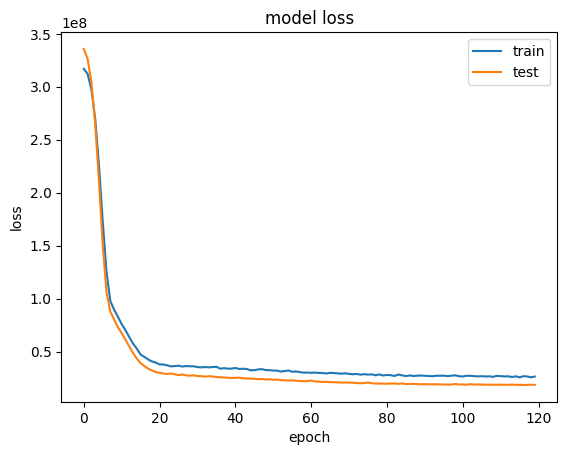

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper right')
plt.show()

In [ ]:
test_mse_score = model.evaluate(x_insurance_test, y_insurance_test)
test_mse_score

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 20366328.0000 - mse: 20366328.0000 


[18692790.0, 18692790.0]

Usando o grafico abaixo podemos ver quão bom foi a predição do modelo. Quanto mais próximo da linha diagonal, melhor é a predição

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


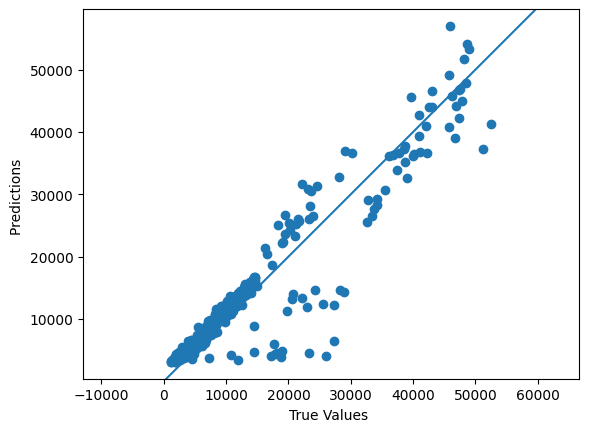

In [ ]:
test_predictions = model.predict(x_insurance_test).flatten()
plt.scatter(y_insurance_test, test_predictions)
plt.xlabel('True Values ')
plt.ylabel('Predictions ')
plt.axis('equal')
plt.xlim(plt.xlim())
plt.ylim(plt.ylim())
_ = plt.plot([0, 60000],[0,60000])